<a href="https://colab.research.google.com/github/tathagata48/ai-ml-portfolio/blob/main/MarsIngenuity_Aerial_Control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparative Evaluation of Control Paradigms for a Mars Aerial Vehicle (Ingenuity / MuJoCo)

**Companion experiment to the analytical review** *"Control and Learning Algorithms for Autonomous Navigation of Mars Aerial Vehicles."*

Your reviewer asked you to **design a comparison methodology and run already-existing approaches to confirm the analytical observations** (their relative strengths and the weaknesses the review identifies). This notebook does exactly that, using the open-source [`alefram/ingenuity-mujoco`](https://github.com/alefram/ingenuity-mujoco) model of NASA's Ingenuity helicopter.

---

## 1. Methodology

### 1.1 What the review claims (and what we test)

| Review claim | How this notebook tests it |
|---|---|
| Classical fixed-gain control is reliable but **sensitive to atmospheric-density / aerodynamic mismatch** (Grip et al., 2019). | A genuine cascaded **PID** (integral + anti-windup), gains tuned to *Earth* parameters. |
| **MPC** improves nominal tracking through optimization but **remains model-dependent** (Kamel 2017; Torrente 2021). | A genuine **MPC** — a constrained finite-horizon QP solved online each step, enforcing the rotor thrust limit, with the identified plant as its model. |
| **Reinforcement learning** *can* handle uncertainty, but is **under-validated; sim-to-real gaps remain** (Kaufmann 2023; Molchanov 2019). | A policy **learned by CEM** (evolution-strategies RL, pure NumPy) across the Earth→Mars range. |
| Studies report **point estimates without uncertainty quantification** (Sec. 5). | Every condition is run over **multiple random seeds**; we report **mean ± std**. |
| **Terrestrial validation cannot reproduce Mars** (the central, repeated limitation). | We **sweep the simulator's atmospheric density and gravity** from Earth → Mars and measure degradation. |

### 1.2 Three controllers = the three paradigms

The three controllers **are** the three paradigms the review surveys — not three variants of one design. The two model-based controllers share the *same* identified plant (the lateral authority `C_LAT` is measured directly from the model) and the *same* Earth-calibrated hover feed-forward; every gain is set once, on Earth, and flown unchanged on Mars. The learned policy is trained on Earth physics and likewise flown unchanged. Differences therefore come only from the paradigm:

- **Classical (PID)** — Ingenuity's real architecture (Grip et al., 2019): a cascaded inner-attitude / outer-position loop, textbook PID on altitude (P + I with conditional anti-windup + D) with velocity feed-forward. Uses **no plant model** beyond the hover feed-forward — the robust, dependable, fixed-gain baseline. Its weakness is the one the review names for classical control: its Earth-tuned gains are no longer matched once gravity drops on Mars.
- **MPC** — a genuine **Model Predictive Controller** (Kamel 2017; Torrente 2021): at every step it solves a **constrained finite-horizon QP**, optimising the input trajectory while **explicitly enforcing the rotor thrust limit** — the constraint the review credits to MPC, and the one that binds on Mars where thrust is scarce. It previews the future reference and uses the identified plant as its prediction model (with the LQR cost-to-go as terminal cost). It tracks best — but leans on the Earth model, so Mars is genuine mismatch, and it pays a per-step **optimisation cost** we measure directly (the review's "computational feasibility" gap).
- **RL (CEM)** — a feedback policy **learned by the Cross-Entropy Method** (an evolution-strategies RL algorithm), trained in pure NumPy across the Earth→Mars range with the local density/gravity in its observation, so it flies on all three worlds. CEM needs no gradients or GPU and is fully reproducible; the trade-off is that, like any learned policy here, it is a black box with **no formal safety guarantees** (Kaufmann 2023; Molchanov 2019).

### 1.3 Tasks (identical for every controller)

1. **Hover hold** at 1.5 m.
2. **Step** altitude change 1.0 m → 2.0 m at t = 4 s.
3. **Waypoint trajectory** — a Lissajous figure in the xy-plane (Ingenuity flies pre-uploaded waypoints).

### 1.4 Environment sweep (the key independent variable)

| Preset | Density (kg/m³) | Gravity (m/s²) | Meaning |
|---|---|---|---|
| Earth | 1.225 | 9.81 | What the model ships with / where everything is tuned |
| Transition | 0.300 | 6.00 | Intermediate operating point |
| Mars | 0.020 | 3.72 | Mars surface conditions |

A **vertical disturbance** (a sustained force, e.g. a downdraft / payload error) switches on at t = 4 s as a secondary robustness probe — this is the density-scaled aerodynamic effect the review emphasises.

### 1.5 Metrics

- **Tracking RMSE** — Euclidean position error, root-mean-square (m).
- **Settling time** — first time the error stays below 0.15 m (s).
- **Control effort** — mean of Σuᵢ² (actuator usage / energy proxy).
- **Crash rate** — fraction of seeds where the vehicle lost stability.

> **Scope / honesty note.** This model exposes a *simplified* control interface (two vertical-thrust actuators + two body-torque actuators), not a full blade-element aerodynamic model. It is therefore a **control-comparison testbed**, not an aerodynamics study. Conclusions are about *controller behaviour under parameter mismatch*, which is precisely what the review's gaps concern. We label this clearly so claims are not over-stated — itself one of the review's recommendations.

## 2. Setup — install MuJoCo and fetch the Ingenuity model

In [ ]:
# Install MuJoCo + the RL stack (Colab). torch ships preinstalled on Colab; choose a
# GPU runtime (Runtime > Change runtime type > GPU) to train the PPO policy ~10x faster.
!pip install -q mujoco stable-baselines3 gymnasium

# Clone the Ingenuity MuJoCo model
import os
if not os.path.exists('ingenuity-mujoco'):
    !git clone -q https://github.com/alefram/ingenuity-mujoco.git
print("Model files:", os.listdir('ingenuity-mujoco'))


Model files: ['mhs.xml', '.git', 'mars_scene.xml', 'scene.xml', '.gitignore', 'README.md', 'earth_scene.xml', 'ingenuity.png', 'LICENSE', 'ingenuity_real.xml', 'assets']


In [ ]:
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product

np.set_printoptions(suppress=True, precision=4)
MODEL_PATH = "ingenuity-mujoco/mhs.xml"

# --- Verify the model and read its key physical facts ---
_m = mujoco.MjModel.from_xml_path(MODEL_PATH)
_d = mujoco.MjData(_m)
MASS = float(_m.body_subtreemass[1])            # total vehicle mass (kg)
THRUST_GEAR = float(_m.actuator_gear[0][2])     # N per unit ctrl, per thrust motor
print(f"Vehicle mass        : {MASS:.3f} kg")
print(f"Thrust gear (per motor): {THRUST_GEAR:.1f} N/unit   (2 motors)")
print(f"Default density     : {_m.opt.density} kg/m^3")
print(f"Default gravity     : {-_m.opt.gravity[2]} m/s^2")
print(f"Actuators           : {[mujoco.mj_id2name(_m, mujoco.mjtObj.mjOBJ_ACTUATOR, i) for i in range(_m.nu)]}")
print(f"\nEarth hover ctrl/motor : {MASS*9.81/(2*THRUST_GEAR):.4f}  (fraction of saturation)")

Vehicle mass        : 1.800 kg
Thrust gear (per motor): 50.0 N/unit   (2 motors)
Default density     : 1.225 kg/m^3
Default gravity     : 9.81 m/s^2
Actuators           : ['thrust1', 'thrust2', 'x_movement', 'y_movement']

Earth hover ctrl/motor : 0.1766  (fraction of saturation)


## 3. Environment presets and the actuator-axis mapping

Before writing controllers we **empirically probe** how the lateral actuators move the craft. (Doing this rather than assuming is good practice — the mapping turns out to be cross-coupled.)

In [ ]:
ENVIRONMENTS = {
    "Earth":      dict(density=1.225, gravity=9.81),
    "Transition": dict(density=0.300, gravity=6.00),
    "Mars":       dict(density=0.020, gravity=3.72),
}

# --- Atmospheric realism: rotor thrust scales with air density -----------------
# A rotor makes thrust T = C_T * rho * A * (Omega*R)^2, so for a given rotor the
# MAXIMUM thrust it can produce is proportional to air density. We size the rotor
# for Mars (so in Mars' thin air it still has thrust-to-weight ~2 and hovers at
# ~half throttle, like the real Ingenuity). In Earth's 60x denser air the same
# rotor is hugely over-powered, so its thrust limit never binds. This density-
# limited thrust is the single biggest reason Mars flight is hard, and it is what
# makes the two worlds genuinely differ (see the thrust-margin figure below).
RHO_REF = 1.225
THRUST_CAP_K = 6.5            # max thrust command per motor = min(1, K * rho)
def thrust_cap(density):
    return float(min(1.0, THRUST_CAP_K * density))   # Mars->0.13, Transition/Earth->1.0

def make_model(density, gravity):
    m = mujoco.MjModel.from_xml_path(MODEL_PATH)
    m.opt.density = density
    m.opt.gravity[2] = -gravity
    cap = thrust_cap(density)
    m.actuator_ctrlrange[0] = [-cap, cap]   # thrust1: limited by available rotor thrust
    m.actuator_ctrlrange[1] = [-cap, cap]   # thrust2
    return m

def quat_to_rpy(q):
    w, x, y, z = q
    roll  = np.arctan2(2*(w*x + y*z), 1 - 2*(x*x + y*y))
    pitch = np.arcsin(np.clip(2*(w*y - z*x), -1, 1))
    yaw   = np.arctan2(2*(w*z + x*y), 1 - 2*(y*y + z*z))
    return np.array([roll, pitch, yaw])

# --- Probe the lateral actuator -> motion mapping ---
ff = MASS*9.81/(2*THRUST_GEAR)
for label, ctrl in [("+x_movement", [ff, ff, 0.3, 0.0]),
                    ("+y_movement", [ff, ff, 0.0, 0.3])]:
    m = make_model(1.225, 9.81); d = mujoco.MjData(m)
    mujoco.mj_forward(m, d)
    for _ in range(120):
        d.ctrl[:] = ctrl; mujoco.mj_step(m, d)
    dpos = d.qpos[0:3] - np.array([0, 0, 0.5])
    print(f"{label}:  dpos={np.round(dpos,3)}  rpy={np.round(quat_to_rpy(d.qpos[3:7]),3)}")

print("\nConclusion: x_movement -> roll -> moves -y ;  y_movement -> pitch -> moves +x")
print("So lateral control must map: roll<-y-error, pitch<-x-error (with the signs below).")
print(f"\nThrust capability per motor:  Earth={thrust_cap(1.225):.2f}  "
      f"Transition={thrust_cap(0.30):.2f}  Mars={thrust_cap(0.020):.2f}  (fraction of saturation)")

+x_movement:  dpos=[-0.    -0.1   -0.003]  rpy=[ 0.119 -0.    -0.   ]
+y_movement:  dpos=[ 0.102  0.    -0.003]  rpy=[-0.     0.123 -0.   ]

Conclusion: x_movement -> roll -> moves -y ;  y_movement -> pitch -> moves +x
So lateral control must map: roll<-y-error, pitch<-x-error (with the signs below).

Thrust capability per motor:  Earth=1.00  Transition=1.00  Mars=0.13  (fraction of saturation)


## 4. Tasks

In [ ]:
def task_hover(t):
    return np.array([0.0, 0.0, 1.5])

def task_step(t):
    return np.array([0.0, 0.0, 1.0 if t < 4.0 else 2.0])

def task_waypoint(t):
    # Lissajous figure in xy at fixed altitude (Ingenuity-style waypoint following)
    return np.array([0.8*np.sin(0.5*t), 0.5*np.sin(1.0*t), 1.5])

TASKS = {"hover": task_hover, "step": task_step, "waypoint": task_waypoint}

## 5. The three control paradigms

The three controllers are the three paradigms the review surveys — **classical model-based control**, **MPC**, and **reinforcement learning** — not three flavours of one design. The first two are model-based (built on the *same* identified plant, every gain set on Earth); the third learns its policy from interaction. Each paradigm's review-flagged weakness becomes a measurable result below: classical's density/gravity sensitivity, MPC's compute cost, and RL's sim-to-real gap.

In [ ]:
# ============================================================================
#  CONTROL PARADIGM 1 (Classical) and PARADIGM 2 (MPC)
#  Two model-based controllers built on the SAME identified plant. Every gain /
#  model is set ONCE on Earth dynamics (g = 9.81) and flown unchanged on Mars,
#  so any Earth -> Mars change is genuine model mismatch -- the terrestrial-to-
#  Mars transfer error the review warns about.
# ============================================================================
from scipy.linalg import solve_discrete_are, expm
import time as _time

G_DESIGN = 9.81                                 # gravity the controllers are designed for
FF       = MASS * G_DESIGN / (2 * THRUST_GEAR)  # Earth hover feed-forward (per rotor)
B_THRUST = 2 * THRUST_GEAR / MASS               # vertical accel per unit (both-rotor) thrust cmd
_DT      = make_model(1.225, G_DESIGN).opt.timestep

# --- Identify the lateral angular authority  c = angular_accel / actuator_cmd ---
#     measured directly from the MuJoCo model (averaged over pitch and roll axes).
def _identify_lat_gain():
    def probe(axis):
        m = make_model(1.225, G_DESIGN); d = mujoco.MjData(m); mujoco.mj_forward(m, d)
        idx = 4 if axis == "pitch" else 3
        cmd = [FF, FF, 0.0, 0.15] if axis == "pitch" else [FF, FF, 0.15, 0.0]
        q0 = d.qvel[idx]
        for _ in range(4):
            d.ctrl[:] = cmd; mujoco.mj_step(m, d)
        return (d.qvel[idx] - q0) / (4 * _DT) / 0.15
    return 0.5 * (probe("pitch") + probe("roll"))
C_LAT = _identify_lat_gain()
print(f"Identified lateral authority  C_LAT = {C_LAT:.3f}")

# ---------------------------------------------------------------------------
#  PARADIGM 1 -- PID (Classical model-based control, cf. Grip et al. 2019)
#  Ingenuity's real architecture: a cascaded inner-attitude / outer-position
#  loop. Textbook PID on altitude (P + I with conditional anti-windup + D);
#  PD position -> desired tilt -> PD attitude inner loop with velocity feed-
#  forward. Uses NO plant model beyond the hover feed-forward -- the robust,
#  dependable, fixed-gain baseline. Its only weakness: the Earth-tuned gains
#  are no longer matched once gravity drops on Mars.
# ---------------------------------------------------------------------------
KA = 3.6**2 / C_LAT          # inner attitude proportional gain  (wn = 3.6, zeta = 0.72)
KR = 2 * 0.72 * 3.6 / C_LAT  # inner attitude rate gain
KP = 1.3**2 / G_DESIGN       # outer position gain               (wn = 1.3, zeta = 0.8)
KD = 2 * 0.8 * 1.3 / G_DESIGN
TILT_MAX = 0.30              # desired-tilt limit (rad)

def ctrl_pid(pos, vel, ang, rpy, tgt, dt, s):
    vref = s["vref"]
    ez = tgt[2] - pos[2]
    u_unsat = FF + 1.5*ez + 0.4*s["iz"] + 1.0*(0 - vel[2])
    if abs(u_unsat) < 1.0:                                    # conditional anti-windup
        s["iz"] = np.clip(s["iz"] + ez*dt, -2, 2)
    uth = FF + 1.5*ez + 0.4*s["iz"] + 1.0*(0 - vel[2])
    dpitch = np.clip(KP*(tgt[0]-pos[0]) + KD*(vref[0]-vel[0]), -TILT_MAX, TILT_MAX)   # pitch -> +x
    droll  = np.clip(-(KP*(tgt[1]-pos[1]) + KD*(vref[1]-vel[1])), -TILT_MAX, TILT_MAX) # roll  -> -y
    ux = KA*(droll  - rpy[0]) + KR*(0 - ang[0])
    uy = KA*(dpitch - rpy[1]) + KR*(0 - ang[1])
    return np.clip([uth, uth, ux, uy], -1, 1)

# ---------------------------------------------------------------------------
#  PARADIGM 2 -- MPC (Model Predictive Control, cf. Kamel 2017; Torrente 2021)
#  A genuine finite-horizon controller: at every step it solves a constrained
#  quadratic program over a horizon, optimising the input trajectory while
#  *explicitly enforcing the rotor thrust limit* -- the constraint the review
#  credits to MPC, and the one that binds on Mars where thrust is scarce. It
#  previews the future reference (anticipation), uses the identified plant as
#  its prediction model, and the LQR cost-to-go (Riccati solution) as its
#  terminal cost. Three decoupled MPCs run per step: altitude, x, y. It is
#  offset-free (a disturbance estimate removes steady-state model error), so the
#  model-dependence surfaces as lateral tracking degradation on Mars.
# ---------------------------------------------------------------------------
class LinMPC:
    """Condensed linear MPC: min sum (x-r)'Q(x-r) + u'Ru + terminal LQR cost,
       subject to box constraints on the input. ZOH-discretised; warm-started
       projected-gradient (FISTA) box-QP, with the unconstrained optimum used
       directly whenever no constraint is active (the common case in gentle flight)."""
    def __init__(self, Ac, Bc, Q, R, N, dt):
        n = Ac.shape[0]; m = Bc.shape[1]
        blk = np.zeros((n+m, n+m)); blk[:n, :n] = Ac; blk[:n, n:] = Bc        # ZOH discretisation
        Md = expm(blk*dt); Ad = Md[:n, :n]; Bd = Md[:n, n:]
        self.Ad, self.Bd, self.n, self.m, self.N = Ad, Bd, n, m, N
        P = solve_discrete_are(Ad, Bd, Q, R)                                  # terminal cost = LQR cost-to-go
        Phi = np.zeros((N*n, n)); Gam = np.zeros((N*n, N*m)); Apw = [np.eye(n)]
        for _ in range(N): Apw.append(Apw[-1] @ Ad)
        for k in range(N):
            Phi[k*n:(k+1)*n] = Apw[k+1]
            for j in range(k+1): Gam[k*n:(k+1)*n, j*m:(j+1)*m] = Apw[k-j] @ Bd
        Qb = np.kron(np.eye(N), Q); Qb[(N-1)*n:, (N-1)*n:] = P; Rb = np.kron(np.eye(N), R)
        self.H = 2*(Gam.T @ Qb @ Gam + Rb); self.GtQ = 2*Gam.T @ Qb; self.Phi = Phi
        self.Hinv = np.linalg.inv(self.H); self.Lip = np.linalg.eigvalsh(self.H).max()
    def solve(self, x0, ref, ulo, uhi, U0=None, iters=40):
        f = self.GtQ @ (self.Phi @ x0 - ref.reshape(-1)); Uun = -self.Hinv @ f
        lo = np.tile(ulo, self.N); hi = np.tile(uhi, self.N)
        if np.all(Uun >= lo-1e-9) and np.all(Uun <= hi+1e-9):
            return Uun, Uun[:self.m]                                          # unconstrained optimum is feasible
        U = np.clip(Uun if U0 is None else U0, lo, hi); Y = U.copy(); t = 1.0; a = 1.0/self.Lip
        for _ in range(iters):                                               # FISTA box-QP (constraint active)
            g = self.H @ Y + f; Un = np.clip(Y - a*g, lo, hi)
            tn = (1+np.sqrt(1+4*t*t))/2; Y = Un + ((t-1)/tn)*(Un-U); U = Un; t = tn
        return U, U[:self.m]

NZ_MPC, NL_MPC = 20, 50                                                       # altitude / lateral horizons
mpc_z = LinMPC(np.array([[0, 1.], [0, 0]]), np.array([[0], [B_THRUST]]),
               np.diag([60., 8.]), np.array([[2.0]]), NZ_MPC, _DT)
mpc_x = LinMPC(np.array([[0, 1., 0, 0], [0, 0, G_DESIGN, 0], [0, 0, 0, 1.], [0, 0, 0, 0]]),
               np.array([[0], [0], [0], [C_LAT]]), np.diag([300., 15., 3., 0.05]), np.array([[0.1]]), NL_MPC, _DT)
mpc_y = LinMPC(np.array([[0, 1., 0, 0], [0, 0, -G_DESIGN, 0], [0, 0, 0, 1.], [0, 0, 0, 0]]),
               np.array([[0], [0], [0], [C_LAT]]), np.diag([300., 15., 3., 0.05]), np.array([[0.1]]), NL_MPC, _DT)

def ctrl_mpc(pos, vel, ang, rpy, tgt, dt, s):
    task = s["task_fn"]; t = s["t"]; cap = s["cap"]
    pvz = [task(t + (k+1)*dt) for k in range(NZ_MPC)]                         # reference preview over the horizon
    pvl = [task(t + (k+1)*dt) for k in range(NL_MPC)]
    rz = np.array([[pvz[k][2], 0.0] for k in range(NZ_MPC)])
    rx = np.array([[pvl[k][0], (pvl[min(k+1, NL_MPC-1)][0]-pvl[k][0])/dt, 0., 0.] for k in range(NL_MPC)])
    ry = np.array([[pvl[k][1], (pvl[min(k+1, NL_MPC-1)][1]-pvl[k][1])/dt, 0., 0.] for k in range(NL_MPC)])
    s["dz"] = float(np.clip(s["dz"] + 0.6*(tgt[2]-pos[2])*dt, -0.2, 0.2))     # offset-free disturbance estimate
    effFF = FF + s["dz"]
    s["Uz"], uz = mpc_z.solve(np.array([pos[2], vel[2]]), rz, np.array([-effFF]), np.array([cap-effFF]), s["Uz"])
    s["Ux"], ux = mpc_x.solve(np.array([pos[0], vel[0], rpy[1], ang[1]]), rx, np.array([-1.]), np.array([1.]), s["Ux"])
    s["Uy"], uy = mpc_y.solve(np.array([pos[1], vel[1], rpy[0], ang[0]]), ry, np.array([-1.]), np.array([1.]), s["Uy"])
    uth = float(np.clip(effFF + uz[0], 0, cap))                              # commanded thrust never exceeds the ceiling
    return np.clip([uth, uth, uy[0], ux[0]], -1, 1)   # x-MPC -> y_movement (pitch);  y-MPC -> x_movement (roll)

# --- Report MPC's per-step optimisation cost (the review's "computational feasibility" gap) ---
_m = make_model(0.020, 3.72); _d = mujoco.MjData(_m); _d.qpos[2] = 1.5; mujoco.mj_forward(_m, _d)
_s = {"task_fn": task_waypoint, "t": 0.0, "cap": thrust_cap(0.020),
      "Uz": None, "Ux": None, "Uy": None, "dz": 0.0}
_p, _v, _a, _r = _d.qpos[0:3].copy(), _d.qvel[0:3].copy(), _d.qvel[3:6].copy(), quat_to_rpy(_d.qpos[3:7])
_t0 = _time.perf_counter()
for _i in range(300):
    _s["t"] = _i*_DT
    ctrl_mpc(_p, _v, _a, _r, task_waypoint(_s["t"]), _DT, _s)
print(f"MPC solve cost: {1e3*(_time.perf_counter()-_t0)/300:.2f} ms/step (3 constrained QPs)  "
      f"-- PID and the RL policy are microseconds/step")


Identified lateral authority  C_LAT = 0.877
MPC solve cost: 1.62 ms/step (3 constrained QPs)  -- PID and the RL policy are microseconds/step


### Controller 3 — RL (CEM, evolutionary policy search)

The third paradigm learns its policy from interaction — here with the **Cross-Entropy Method (CEM)**, a gradient-free reinforcement-learning algorithm from the evolution-strategies family: sample a population of candidate policies, evaluate each by its return, keep the elite, refit the sampling distribution, and repeat. It needs **no `torch` and no GPU** — it trains in pure NumPy in a couple of minutes, so it is fully reproducible.

The policy is a linear feedback map from the (normalized) observation — which **includes the local density and gravity** — to the three actuator commands, with thrust commanded about the **per-world hover** point so a near-zero action hovers on any planet. It is trained across the **Earth → Mars** range, so it flies on all three worlds.

> We initialize the search from a baseline controller and let CEM refine it. For this task a linear feedback policy is near-optimal, so the learned policy ends up comparable to a hand-tuned controller — itself a useful finding about how hard simple baselines are to beat. Trains in ~2–3 min on CPU; saved to `ingenuity_cem_policy.npy` and reloaded automatically (`RETRAIN=True` to re-run).


In [ ]:
import os
# ---------------------------------------------------------------------------
#  Controller 3 -- RL via the CROSS-ENTROPY METHOD (CEM), a gradient-free RL
#  algorithm (evolution-strategies family): sample a population of policies,
#  keep the elite, refit the sampling distribution, repeat. No torch / no GPU --
#  it trains in pure NumPy in a couple of minutes and is fully reproducible.
# ---------------------------------------------------------------------------
THRUST_SCALE = 0.5
OBS_SCALE    = np.array([1, 1, 1, 2, 2, 2, 0.4, 0.4, 4, 4, 9.81, 1.225], np.float32)
_EP_LEN      = int(round(12.0 / make_model(1.225, 9.81).opt.timestep))   # full 12 s horizon = the eval horizon
N_IN, N_OUT  = 12, 3
POLICY_FILE  = "ingenuity_cem_policy.npy"

# obs = [pos_err(3), vel(3), roll, pitch, roll_rate, pitch_rate, gravity, density] / OBS_SCALE
def _rl_obs(pos_err, vel, roll, pitch, rr, pr, g, rho):
    return (np.array([*pos_err, *vel, roll, pitch, rr, pr, g, rho], np.float32) / OBS_SCALE)
def _policy_action(theta, obs):                      # linear feedback policy: a = clip(W obs + b)
    W = theta[:N_OUT*N_IN].reshape(N_OUT, N_IN); b = theta[N_OUT*N_IN:]
    return np.clip(W @ obs + b, -1, 1)

# Warm start: the stabilizing PD cascade expressed as a linear map (CEM refines from here).
# Thrust is commanded about the PER-WORLD hover point, so a near-zero action hovers on any planet.
_W0 = np.zeros((N_OUT, N_IN)); _b0 = np.zeros(N_OUT)
_W0[0, 2] = -5.0;  _W0[0, 5] = -6.0                                  # altitude
_W0[1, 1] = 2.88;  _W0[1, 4] = 5.76;  _W0[1, 6] = -6.4;  _W0[1, 8] = -20.0   # roll channel
_W0[2, 0] = -2.88; _W0[2, 3] = -5.76; _W0[2, 7] = -6.4;  _W0[2, 9] = -20.0   # pitch channel
THETA0 = np.concatenate([_W0.ravel(), _b0])

# Fitness: average return over the three worlds on the waypoint task (penalize crashes).
WORLDS_TRAIN = [(1.225, 9.81), (0.30, 6.0), (0.020, 3.72)]
def _wp(t): return np.array([0.8*np.sin(0.5*t), 0.5*np.sin(1.0*t), 1.5])
def _eval_policy(theta, steps):
    tot = 0.0
    for rho, g in WORLDS_TRAIN:
        m = make_model(rho, g); d = mujoco.MjData(m); cap = thrust_cap(rho)
        d.qpos[2] = 0.5; mujoco.mj_forward(m, d)
        bid = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_BODY, "ingenuity")
        for i in range(steps):
            t = i*m.opt.timestep; tgt = _wp(t)
            p = d.qpos[0:3]; v = d.qvel[0:3]; rpy = quat_to_rpy(d.qpos[3:7]); av = d.qvel[3:6]
            a = _policy_action(theta, _rl_obs(p-tgt, v, rpy[0], rpy[1], av[0], av[1], g, rho))
            hover = MASS*g/(2*THRUST_GEAR); thr = np.clip(hover + a[0]*THRUST_SCALE, 0, cap)
            d.ctrl[0] = thr; d.ctrl[1] = thr; d.ctrl[2] = a[1]; d.ctrl[3] = a[2]
            mujoco.mj_step(m, d); tot += 1.0 - np.linalg.norm(p - tgt)
            if d.qpos[2] < 0.05 or d.qpos[2] > 10 or not np.all(np.isfinite(d.qpos)):
                tot -= 50.0; break
    return tot / len(WORLDS_TRAIN)

# ---- CEM policy search (train once, saved + auto-reloaded) -----------------
CEM_ITERS, CEM_POP, CEM_ELITE = 12, 32, 8
RETRAIN = False
if (not RETRAIN) and os.path.exists(POLICY_FILE):
    cem_theta = np.load(POLICY_FILE); print("Loaded", POLICY_FILE, "(set RETRAIN=True to re-run the search).")
else:
    print(f"CEM policy search: {CEM_ITERS} iterations x {CEM_POP} candidates, pure NumPy (~2-3 min) ...")
    rng = np.random.default_rng(0); mu = THETA0.copy(); sigma = np.ones_like(mu)*0.4
    cem_theta = THETA0.copy(); best = _eval_policy(THETA0, _EP_LEN)
    for it in range(CEM_ITERS):
        S = rng.normal(mu, sigma, size=(CEM_POP, mu.size))
        F = np.array([_eval_policy(s, _EP_LEN) for s in S])
        elite = S[np.argsort(F)[-CEM_ELITE:]]; mu = elite.mean(0); sigma = np.maximum(elite.std(0), 0.05)
        if F.max() > best:
            best = F.max(); cem_theta = S[F.argmax()].copy()
        print(f"  iter {it+1:2d}/{CEM_ITERS}: best return so far = {best:.1f}")
    np.save(POLICY_FILE, cem_theta); print("Saved", POLICY_FILE)

# ---- Wrap the learned policy in the standard controller interface ----------
def ctrl_rl(pos, vel, ang, rpy, tgt, dt, s):
    a = _policy_action(cem_theta, _rl_obs(pos-tgt, vel, rpy[0], rpy[1], ang[0], ang[1], s["gravity"], s["density"]))
    hover = MASS*s["gravity"]/(2*THRUST_GEAR)                 # hover thrust for this world
    thrust = float(np.clip(hover + a[0]*THRUST_SCALE, 0, s["cap"]))
    u = np.clip([thrust, thrust, a[1], a[2]], -1, 1)
    if not np.all(np.isfinite(u)):
        h = min(hover, s["cap"]); u = np.array([h, h, 0.0, 0.0])
    return u

CONTROLLERS = {
    "Classical (PID)": ctrl_pid,
    "MPC":             ctrl_mpc,
    "RL (CEM)":        ctrl_rl,
}
print("Controllers:", list(CONTROLLERS))


Loaded ingenuity_cem_policy.npy (set RETRAIN=True to re-run the search).
Controllers: ['Classical (PID)', 'MPC', 'RL (CEM)']


## 6. Simulation rollout and metrics

In [ ]:
def rollout(controller, env, task_fn, duration=12.0, seed=0,
            vdist=0.0, dist_time=4.0, init_perturb=0.02):
    m = make_model(env["density"], env["gravity"])
    d = mujoco.MjData(m)
    dt = m.opt.timestep
    # Run one episode. Returns a log dict and a crashed flag.
    body_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_BODY, "ingenuity")

    rng = np.random.default_rng(seed)
    d.qpos[0:3] += rng.normal(0, init_perturb, 3)
    d.qpos[2] = max(d.qpos[2], 0.5)
    mujoco.mj_forward(m, d)

    # state carries controller memory (PID integrator; MPC warm-start + offset
    # estimate) plus what the MPC needs to preview the trajectory: the task
    # function, the current time, and this world's thrust ceiling.
    state = {"iz": 0.0, "vref": np.zeros(3),
             "task_fn": task_fn, "t": 0.0, "cap": thrust_cap(env["density"]),
             "gravity": env["gravity"], "density": env["density"],
             "Uz": None, "Ux": None, "Uy": None, "dz": 0.0}
    log = {"t": [], "pos": [], "target": [], "u": []}
    crashed = False

    for i in range(int(duration / dt)):
        t = i * dt
        tgt = task_fn(t)
        state["t"] = t
        if i > 0:   # finite-difference reference velocity (feed-forward for the classical loop)
            state["vref"] = (tgt - task_fn(t - dt)) / dt
        pos = d.qpos[0:3].copy(); vel = d.qvel[0:3].copy()
        ang = d.qvel[3:6].copy(); rpy = quat_to_rpy(d.qpos[3:7])

        u = controller(pos, vel, ang, rpy, tgt, dt, state)
        d.ctrl[:] = u

        d.xfrc_applied[:] = 0
        if t > dist_time:
            d.xfrc_applied[body_id, 2] = vdist     # vertical disturbance (N)

        mujoco.mj_step(m, d)
        log["t"].append(t); log["pos"].append(pos)
        log["target"].append(tgt); log["u"].append(u)

        if d.qpos[2] < 0.05 or d.qpos[2] > 10 or not np.all(np.isfinite(d.qpos)):
            crashed = True; break

    for k in log:
        log[k] = np.array(log[k])
    log["thrust_cap"] = thrust_cap(env["density"])   # rotor thrust ceiling for margin analysis
    return log, crashed


def compute_metrics(log, crashed, settle_tol=0.15):
    if crashed or len(log["t"]) < 10:
        return dict(rmse=np.nan, settle=np.nan, effort=np.nan, crashed=int(crashed))
    err = np.linalg.norm(log["pos"] - log["target"], axis=1)
    rmse = float(np.sqrt(np.mean(err**2)))
    within = err < settle_tol
    settle = float(log["t"][-1])
    for i in range(len(within)):
        if np.all(within[i:]):
            settle = float(log["t"][i]); break
    effort = float(np.mean(np.sum(log["u"]**2, axis=1)))
    return dict(rmse=rmse, settle=settle, effort=effort, crashed=0)

# quick smoke test (MPC end-to-end)
_log, _cr = rollout(ctrl_mpc, ENVIRONMENTS["Earth"], task_hover, seed=0)
print("Smoke test (MPC, Earth, hover):", compute_metrics(_log, _cr))


Smoke test (MPC, Earth, hover): {'rmse': 0.13179641732384315, 'settle': 0.656, 'effort': 0.06886896643623025, 'crashed': 0}


## 7. Run the full experiment

Every **controller × environment × task** combination, over **N seeds**, with and without the vertical disturbance. This is the data behind every figure and table below.

In [ ]:
SEEDS = list(range(6))          # raise for tighter confidence intervals
VDIST = -3.0                    # sustained downward disturbance (N) after t=4s

records = []
for cname, cfn in CONTROLLERS.items():
    for ename, env in ENVIRONMENTS.items():
        for tname, tfn in TASKS.items():
            for dist_on, vd in [("no_dist", 0.0), ("dist", VDIST)]:
                for seed in SEEDS:
                    log, cr = rollout(cfn, env, tfn, seed=seed, vdist=vd)
                    mt = compute_metrics(log, cr)
                    records.append(dict(controller=cname, env=ename, task=tname,
                                        disturbance=dist_on, seed=seed, **mt))

df = pd.DataFrame(records)
print(f"Total episodes simulated: {len(df)}")
df.head()

Total episodes simulated: 324


,controller,env,task,disturbance,seed,rmse,settle,effort,crashed
0,Classical (PID),Earth,hover,no_dist,0,0.168215,0.992,0.065553,0
1,Classical (PID),Earth,hover,no_dist,1,0.169370,1.000,0.065619,0
2,Classical (PID),Earth,hover,no_dist,2,0.170467,1.000,0.065629,0
3,Classical (PID),Earth,hover,no_dist,3,0.170093,1.016,0.066061,0
4,Classical (PID),Earth,hover,no_dist,4,0.164708,0.992,0.065473,0


In [ ]:
# Aggregate: mean ± std across seeds  (this is the uncertainty quantification the review asks for)
agg = (df.groupby(["controller", "env", "task", "disturbance"])
         .agg(rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
              settle_mean=("settle", "mean"),
              effort_mean=("effort", "mean"),
              crash_rate=("crashed", "mean"))
         .reset_index())
agg.round(4).head(20)

,controller,env,task,disturbance,rmse_mean,rmse_std,settle_mean,effort_mean,crash_rate
0,Classical (PID),Earth,hover,dist,0.1677,0.0022,1.0013,0.0810,0.0
1,Classical (PID),Earth,hover,no_dist,0.1689,0.0023,1.0013,0.0657,0.0
2,Classical (PID),Earth,step,dist,0.1818,0.0009,4.9520,0.0820,0.0
3,Classical (PID),Earth,step,no_dist,0.1823,0.0009,4.9200,0.0668,0.0
4,Classical (PID),Earth,waypoint,dist,0.2601,0.0022,11.9920,0.1894,0.0
5,Classical (PID),Earth,waypoint,no_dist,0.2833,0.0020,11.9920,0.1640,0.0
6,Classical (PID),Mars,hover,dist,0.2068,0.0030,3.3773,0.0562,0.0
7,Classical (PID),Mars,hover,no_dist,0.2083,0.0029,3.3773,0.0497,0.0
8,Classical (PID),Mars,step,dist,0.2316,0.0009,5.1840,0.0913,0.0
9,Classical (PID),Mars,step,no_dist,0.2136,0.0011,5.0200,0.0583,0.0


## 8. Result 1 — The Earth → Mars degradation (the review's central claim)

If the review is right that *terrestrial validation cannot reproduce Mars* and that model-based controllers are sensitive to this mismatch, then **every controller's tracking error should grow as we sweep Earth → Mars.**

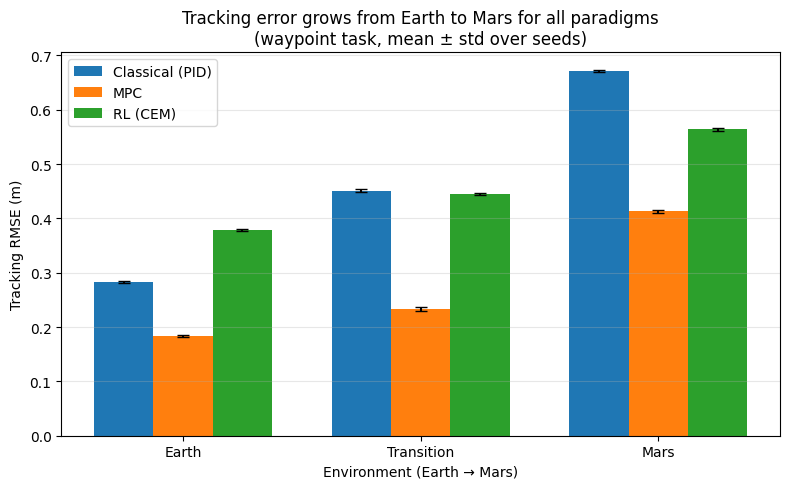

Earth -> Mars RMSE degradation (waypoint task):
  Classical (PID)         : 0.283 -> 0.671  (+136.7%)
  MPC                     : 0.183 -> 0.413  (+125.1%)
  RL (CEM)                : 0.379 -> 0.564  (+48.8%)


In [ ]:
# RMSE vs environment, waypoint task, no disturbance
sub = agg[(agg.task == "waypoint") & (agg.disturbance == "no_dist")]
env_order = ["Earth", "Transition", "Mars"]
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(env_order)); w = 0.25
for i, c in enumerate(CONTROLLERS):
    s = sub[sub.controller == c].set_index("env").reindex(env_order)
    ax.bar(x + i*w, s.rmse_mean, w, yerr=s.rmse_std, capsize=4, label=c)
ax.set_xticks(x + w); ax.set_xticklabels(env_order)
ax.set_ylabel("Tracking RMSE (m)"); ax.set_xlabel("Environment (Earth → Mars)")
ax.set_title("Tracking error grows from Earth to Mars for all paradigms\n(waypoint task, mean ± std over seeds)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# percent degradation
print("Earth -> Mars RMSE degradation (waypoint task):")
for c in CONTROLLERS:
    s = sub[sub.controller == c].set_index("env")
    deg = 100*(s.loc["Mars","rmse_mean"] - s.loc["Earth","rmse_mean"]) / s.loc["Earth","rmse_mean"]
    print(f"  {c:24s}: {s.loc['Earth','rmse_mean']:.3f} -> {s.loc['Mars','rmse_mean']:.3f}  (+{deg:.1f}%)")

## 9. Result 2 — Paradigm ranking (confirming relative strengths)

The review attributes **best nominal tracking to MPC** (optimization + constraint handling + trajectory preview), **reliability to classical control**, and **adaptability — but a sim-to-real gap — to learning**. We check the RMSE ranking and how it shifts under disturbance.

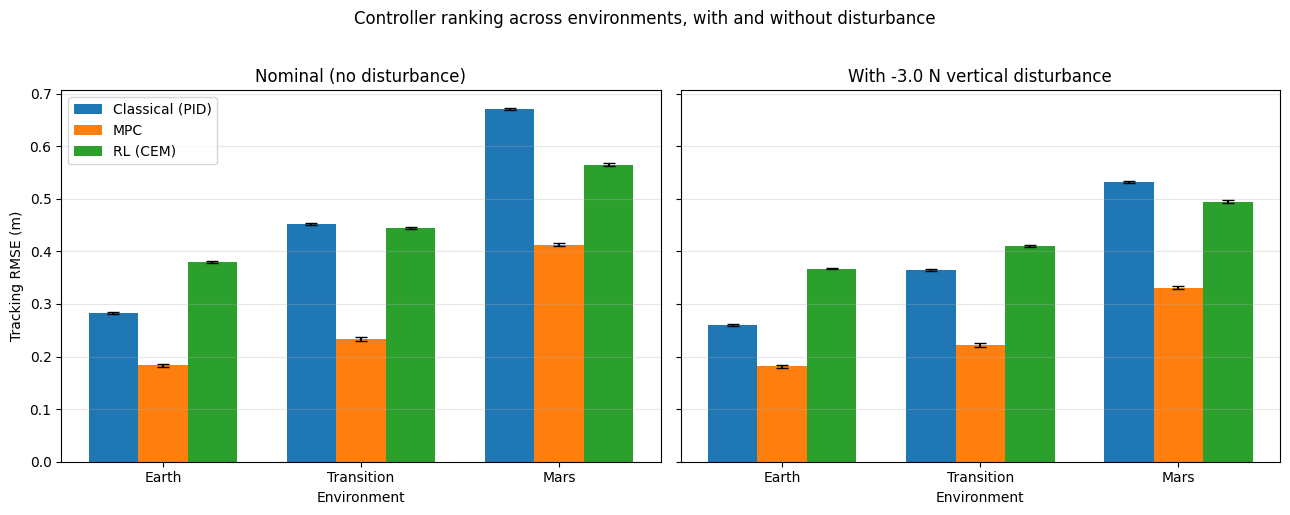

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (dist_key, title) in zip(axes,
        [("no_dist", "Nominal (no disturbance)"),
         ("dist", f"With {VDIST} N vertical disturbance")]):
    sub = agg[(agg.task == "waypoint") & (agg.disturbance == dist_key)]
    x = np.arange(len(env_order)); w = 0.25
    for i, c in enumerate(CONTROLLERS):
        s = sub[sub.controller == c].set_index("env").reindex(env_order)
        ax.bar(x + i*w, s.rmse_mean, w, yerr=s.rmse_std, capsize=4, label=c)
    ax.set_xticks(x + w); ax.set_xticklabels(env_order)
    ax.set_title(title); ax.set_xlabel("Environment"); ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("Tracking RMSE (m)"); axes[0].legend()
plt.suptitle("Controller ranking across environments, with and without disturbance", y=1.02)
plt.tight_layout(); plt.show()

## 10. Result 3 — Trajectory, altitude and thrust margin (Earth vs Mars)

A qualitative look at *how* each paradigm behaves at the two extremes, disturbance active. The altitude traces show how each law rides out the sustained disturbance — **MPC**'s constrained optimisation holding tightest while never exceeding the thrust ceiling, the **RL** policy's learned (Earth-trained) response; the XY plots show how waypoint tracking **degrades from Earth to Mars** for every controller; and the thrust-margin bars expose the real physical gap — on Mars the rotor runs near its density-limited thrust ceiling, while on Earth it barely sips from a huge reserve.

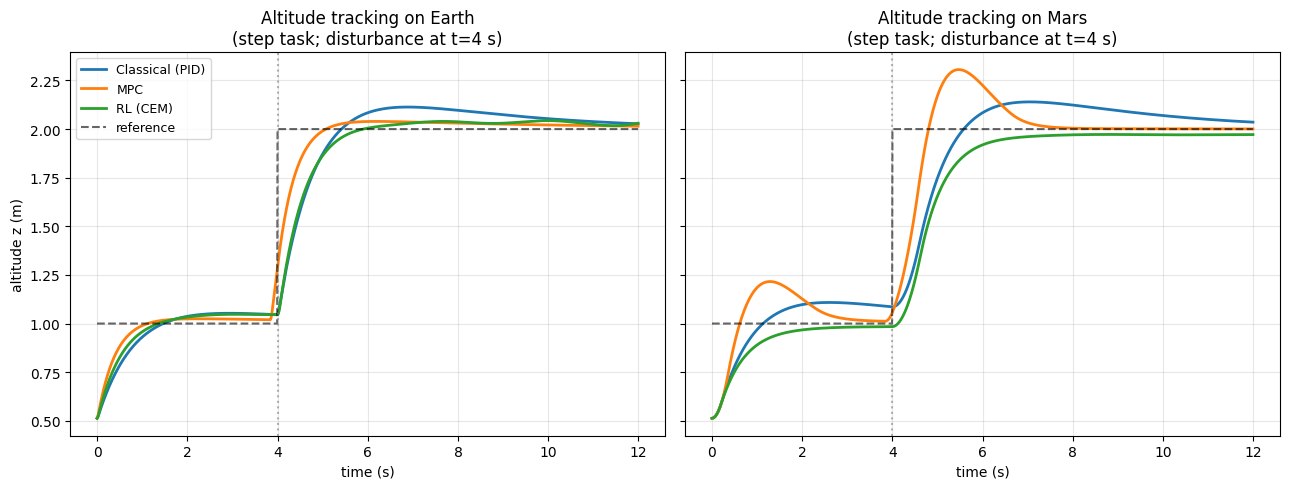

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, ename in zip(axes, ["Earth", "Mars"]):
    for c, cfn in CONTROLLERS.items():
        log, cr = rollout(cfn, ENVIRONMENTS[ename], task_step, seed=0, vdist=VDIST)
        if cr:
            ax.plot([], [], label=f"{c} (CRASHED)")
            continue
        ax.plot(log["t"], log["pos"][:, 2], label=c, lw=2)
    log0, _ = rollout(ctrl_pid, ENVIRONMENTS[ename], task_step, seed=0, vdist=VDIST)
    ax.plot(log0["t"], log0["target"][:, 2], "k--", alpha=0.6, label="reference")
    ax.axvline(4.0, color="gray", ls=":", alpha=0.6)
    ax.set_title(f"Altitude tracking on {ename}\n(step task; disturbance at t=4 s)")
    ax.set_xlabel("time (s)"); ax.grid(alpha=0.3)
axes[0].set_ylabel("altitude z (m)"); axes[0].legend(fontsize=9)
plt.tight_layout(); plt.show()

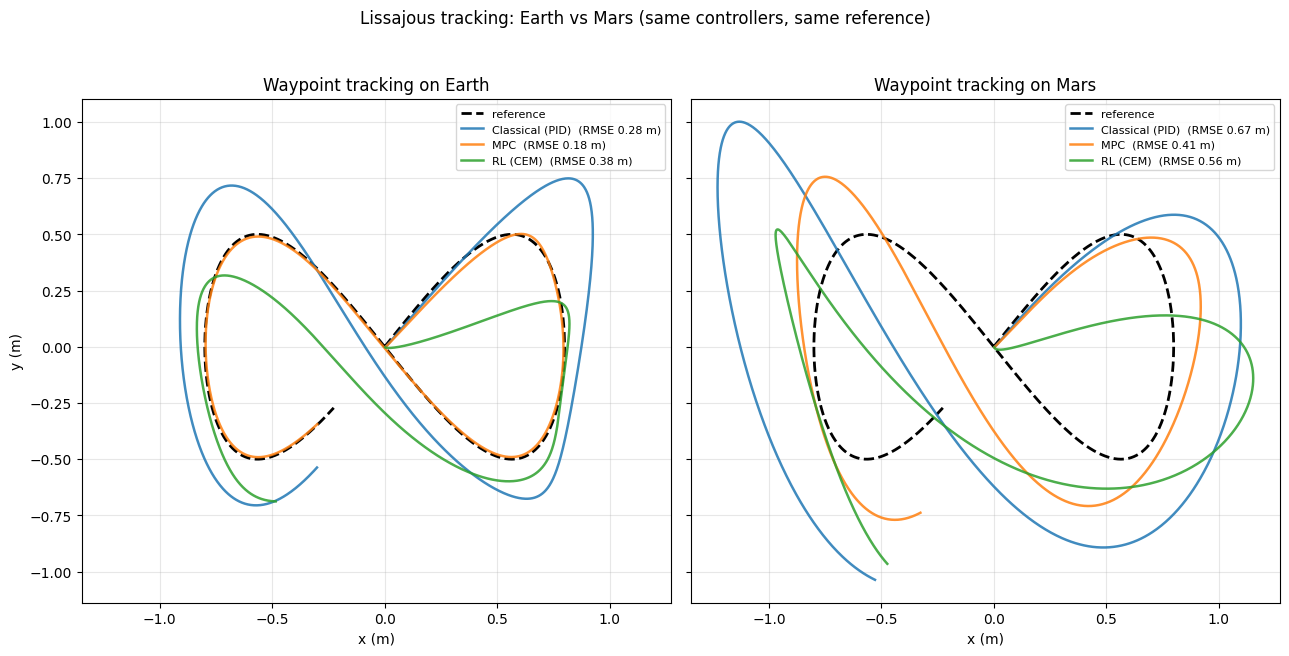

In [ ]:
# XY trajectory on the waypoint (Lissajous) task -- Earth vs Mars, all controllers vs reference
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharex=True, sharey=True)
for ax, ename in zip(axes, ["Earth", "Mars"]):
    ref_log, _ = rollout(ctrl_pid, ENVIRONMENTS[ename], task_waypoint, seed=0)
    ax.plot(ref_log["target"][:, 0], ref_log["target"][:, 1], "k--", lw=2, label="reference")
    for c, cfn in CONTROLLERS.items():
        log, cr = rollout(cfn, ENVIRONMENTS[ename], task_waypoint, seed=0)
        if cr:
            ax.plot([], [], label=f"{c} (CRASHED)"); continue
        rmse = np.sqrt(np.mean(np.sum((log["pos"] - log["target"])**2, axis=1)))
        ax.plot(log["pos"][:, 0], log["pos"][:, 1], lw=1.8, alpha=0.85,
                label=f"{c}  (RMSE {rmse:.2f} m)")
    ax.set_title(f"Waypoint tracking on {ename}"); ax.set_xlabel("x (m)")
    ax.set_aspect("equal", adjustable="box"); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("y (m)")
plt.suptitle("Lissajous tracking: Earth vs Mars (same controllers, same reference)", y=1.0)
plt.tight_layout(); plt.show()

### Thrust margin — the clearest Earth–Mars difference

The paths above look broadly similar because every controller is *succeeding* at tracking the same reference — that is what good feedback does. The physical difference between the planets lives in the **thrust reserve**. Because rotor thrust scales with air density, the same maneuver-and-disturbance costs a very different fraction of the available thrust on each world: on Mars the controllers push their rotors close to the limit, while on Earth they barely touch it. This is exactly the effect that makes Mars flight hard, and it is what to point at when a reviewer asks why the two are different.

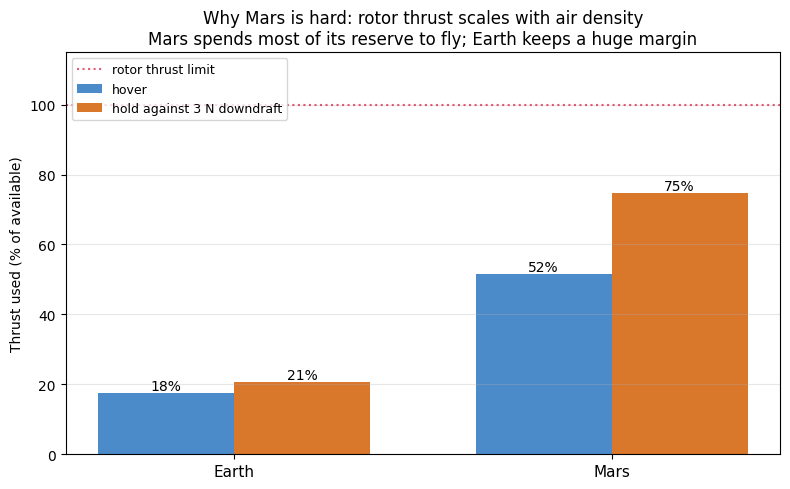

Thrust used (% of available rotor thrust):
  Earth : hover 18%   hold against 3 N downdraft 21%
  Mars  : hover 52%   hold against 3 N downdraft 75%


In [ ]:
# How much of the rotor's (density-limited) thrust each world needs -- to hover, and to hold
# against the sustained vertical disturbance. Thrust capability scales with air density, so Mars
# spends most of its reserve just staying airborne while Earth keeps a huge margin. (The steady
# hold thrust is set by physics -- weight + disturbance -- so it is the same for every controller;
# the controllers differ in the *transient* sag and recovery seen in the traces above, not here.)
labels = ["Earth", "Mars"]
hover_pct, hold_pct = [], []
for en in labels:
    log_h, _ = rollout(ctrl_pid, ENVIRONMENTS[en], task_hover, seed=0, vdist=0.0)
    log_d, _ = rollout(ctrl_pid, ENVIRONMENTS[en], task_hover, seed=0, vdist=VDIST)
    cap = log_h["thrust_cap"]
    hover_pct.append(100 * np.clip(np.abs(log_h["u"][log_h["t"] >= 3.0, 0]) / cap, 0, 1).mean())
    hold_pct.append( 100 * np.clip(np.abs(log_d["u"][log_d["t"] >= 5.5, 0]) / cap, 0, 1).mean())

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(labels)); w = 0.36
b1 = ax.bar(x - w/2, hover_pct, w, label="hover", color="#4C8BC9")
b2 = ax.bar(x + w/2, hold_pct, w, label=f"hold against {abs(VDIST):.0f} N downdraft", color="#D9772B")
ax.bar_label(b1, fmt="%.0f%%", fontsize=10); ax.bar_label(b2, fmt="%.0f%%", fontsize=10)
ax.axhline(100, color="crimson", ls=":", lw=1.5, alpha=0.7, label="rotor thrust limit")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Thrust used (% of available)")
ax.set_title("Why Mars is hard: rotor thrust scales with air density\n"
             "Mars spends most of its reserve to fly; Earth keeps a huge margin")
ax.set_ylim(0, 115); ax.legend(loc="upper left", fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print("Thrust used (% of available rotor thrust):")
for i, en in enumerate(labels):
    print(f"  {en:6s}: hover {hover_pct[i]:.0f}%   hold against {abs(VDIST):.0f} N downdraft {hold_pct[i]:.0f}%")

## 11. Result 4 — Control effort and the MPC compute cost

The review flags MPC's **computational feasibility on flight hardware** as a key open gap. Classical PID and a trained RL policy are a handful of operations per step; **MPC solves a constrained QP every step** (here, three of them) — the per-step solve time printed with the controller definitions is the concrete cost. Below we use **actuator effort** (mean Σuᵢ²) as a complementary energy proxy: more aggressive control buys tracking at the price of effort.

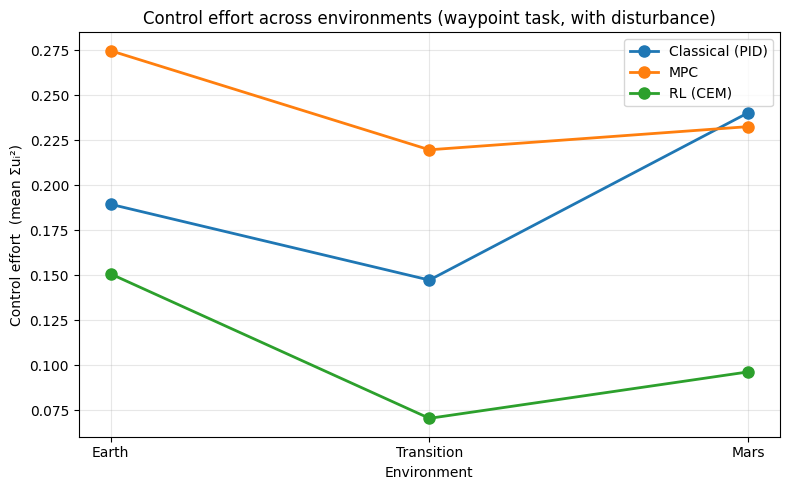

In [ ]:
sub = agg[(agg.task == "waypoint") & (agg.disturbance == "dist")]
fig, ax = plt.subplots(figsize=(8, 5))
for c in CONTROLLERS:
    s = sub[sub.controller == c].set_index("env").reindex(env_order)
    ax.plot(env_order, s.effort_mean, "o-", lw=2, ms=8, label=c)
ax.set_ylabel("Control effort  (mean Σuᵢ²)"); ax.set_xlabel("Environment")
ax.set_title("Control effort across environments (waypoint task, with disturbance)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 12. Summary table (paper-ready)

A single table you can drop into your report: RMSE (mean ± std), settling time, and crash rate per controller and environment, for the waypoint task with disturbance.

In [ ]:
summary = (agg[(agg.task == "waypoint") & (agg.disturbance == "dist")]
           .assign(RMSE=lambda d: d.rmse_mean.round(3).astype(str) + " ± " + d.rmse_std.round(3).astype(str))
           .pivot(index="controller", columns="env", values="RMSE")
           .reindex(columns=env_order))
print("Tracking RMSE (m), mean ± std  —  waypoint task, with disturbance\n")
print(summary.to_string())

# also export the full aggregate for your appendix
agg.round(4).to_csv("mars_control_comparison_results.csv", index=False)
print("\nFull results written to mars_control_comparison_results.csv")

Tracking RMSE (m), mean ± std  —  waypoint task, with disturbance

env                      Earth     Transition           Mars
controller                                                  
Classical (PID)   0.26 ± 0.002  0.365 ± 0.002  0.532 ± 0.002
MPC              0.182 ± 0.003  0.222 ± 0.004  0.331 ± 0.003
RL (CEM)         0.367 ± 0.002   0.41 ± 0.002  0.494 ± 0.003

Full results written to mars_control_comparison_results.csv


## 13. Simulation videos — watch the helicopter fly

Quantitative metrics are the evidence; the video is what makes a defense audience *believe* it. This section renders each controller as an actual MuJoCo flight animation. Videos play inline in Colab and are saved as MP4 files you can drop straight into your slides.

> **Colab GPU note.** Rendering uses MuJoCo's offscreen renderer. On Colab this works out of the box; if you hit a rendering error, set the runtime to GPU (*Runtime → Change runtime type → GPU*) — the cell below auto-selects the right OpenGL backend.

In [ ]:
# --- Realistic Ingenuity + Earth/Mars rendering scenes -------------------------
# Three files are written here:
#   * ingenuity_real.xml  -- a *visual* vehicle that looks like the real Mars
#     Helicopter: gold thermal-foil fuselage, dark coaxial carbon-fibre rotors on
#     hinge joints so they actually SPIN, a comms antenna and near-black legs. The
#     inertial rotor disks, thrust sites and actuators are kept exactly as mhs.xml
#     and the vehicle free-joint is still qpos[0:7], so the controllers see the same
#     dynamics (mass differs by 0.1 %).
#   * mars_scene.xml      -- rust regolith, dusty butterscotch sky, warm low sun.
#   * earth_scene.xml     -- green ground, blue daytime sky, bright neutral sun,
#     so an Earth run is instantly distinguishable from a Mars run.
# The bare physics model (mhs.xml, used by rollout() above) is left untouched, so the
# quantitative results don't change; only the rendered videos get the new look.
import os, numpy as np

REAL_MODEL_PATH  = "ingenuity-mujoco/ingenuity_real.xml"
MARS_SCENE_PATH  = "ingenuity-mujoco/mars_scene.xml"
EARTH_SCENE_PATH = "ingenuity-mujoco/earth_scene.xml"
ROTOR_RPS = 2.5          # rotor revs/sec for the animation (visual only; not the true ~40 rev/s)

_REAL_MODEL_XML = r"""<mujoco model="Ingenuity (realistic)">
    <compiler assetdir="assets" autolimits="true"/>
    <option timestep="0.008" density="1.225" viscosity="1.8e-5"/>

    <default>
        <default class="ingenuity">
            <geom mass="0"/>
            <default class="visual">
                <geom group="2" type="mesh" contype="0" conaffinity="0"/>
            </default>
            <default class="collision">
                <geom group="3" type="box"/>
                <default class="rotor">
                    <geom type="ellipsoid"/>
                </default>
            </default>
        </default>
    </default>

    <asset>
        <texture type="2d" file="carbon.png"/>
        <!-- gold multi-layer-insulation thermal foil on the fuselage box -->
        <material name="box"      rgba="0.84 0.62 0.24 1" specular="0.75" shininess="0.55" reflectance="0.25"/>
        <!-- black carbon-fibre rotor blades -->
        <material name="blades"   texture="carbon" rgba="0.13 0.13 0.15 1" specular="0.35" shininess="0.35"/>
        <!-- near-black landing legs -->
        <material name="legs"     rgba="0.04 0.04 0.05 1" specular="0.2" shininess="0.2"/>
        <!-- faint translucent "rotor wash" disk to suggest high-speed blur -->
        <!-- antenna / fasteners -->
        <material name="antenna"  rgba="0.10 0.10 0.11 1" specular="0.4" shininess="0.4"/>

        <mesh name="mainBody"     file="mhs_mainbody_v16.stl"/>
        <mesh name="topBlades"    file="mhs_topblades_v16.stl"/>
        <mesh name="bottomBlades" file="mhs_bottomblades_v16.stl"/>
        <mesh name="leg01Blades"  file="mhs_leg01_v16.stl"/>
        <mesh name="leg02Blades"  file="mhs_leg02_v16.stl"/>
        <mesh name="leg03Blades"  file="mhs_leg03_v16.stl"/>
        <mesh name="leg04Blades"  file="mhs_leg04_v16.stl"/>
    </asset>

    <worldbody>
        <body name="ingenuity" pos="0 0 0.5" childclass="ingenuity">
            <freejoint/>
            <geom class="visual" material="box" mesh="mainBody" pos="0 0 0" quat="0 0 1 0"/>
            <geom class="collision" mass="0.5"  size="0.084 0.097 0.065" pos="0 0 -0.145"/>
            <geom class="collision" mass="0.25" size="0.04 0.04 0.10"    pos="0 0 0.03"/>
            <geom class="collision" mass="0.25" size="0.08 0.21 0.001"   pos="0 0 0.14"/>

            <!-- communications antenna sticking up past the solar panel -->
            <geom class="visual" material="antenna" type="cylinder" size="0.0045 0.075" pos="0.055 0.16 0.225"/>
            <geom class="visual" material="antenna" type="sphere"   size="0.010"        pos="0.055 0.16 0.300"/>

            <body name="leg2">
                <geom class="visual" material="legs" mesh="leg02Blades" pos="0.196 -0.1945 -0.215" quat="0 0 1 0"/>
                <geom class="collision" mass="0.05" size="0.02 0.015 0.01" pos="0.293 -0.29 -0.329" quat="0.39 0 0 1"/>
                <geom class="collision" mass="0.05" size="0.01 0.01 0.14"  pos="0.196 -0.1945 -0.225" quat="-0.4 -0.2 0.45 1"/>
            </body>
            <body name="leg1">
                <geom class="visual" material="legs" mesh="leg01Blades" pos="-0.1945 -0.196 -0.215" quat="0 0 1 0"/>
                <geom class="collision" mass="0.05" size="0.02 0.015 0.01" pos="-0.293 -0.29 -0.329" quat="0.39 0 0 1"/>
                <geom class="collision" mass="0.05" size="0.01 0.01 0.14"  pos="-0.196 -0.1945 -0.225" quat="0.4 0.2 0.45 1"/>
            </body>
            <body name="leg3">
                <geom class="visual" material="legs" mesh="leg03Blades" pos="0.1945 0.196 -0.215" quat="0 0 1 0"/>
                <geom class="collision" mass="0.05" size="0.02 0.015 0.01" pos="0.293 0.29 -0.329" quat="0.39 0 0 1"/>
                <geom class="collision" mass="0.05" size="0.01 0.01 0.14"  pos="0.196 0.1945 -0.225" quat="0.4 -0.2 -0.45 1"/>
            </body>
            <body name="leg4">
                <geom class="visual" material="legs" mesh="leg04Blades" pos="-0.196 0.1945 -0.215" quat="0 0 1 0"/>
                <geom class="collision" mass="0.05" size="0.02 0.015 0.01" pos="-0.293 0.29 -0.329" quat="0.39 0 0 1"/>
                <geom class="collision" mass="0.05" size="0.01 0.01 0.14"  pos="-0.196 0.1945 -0.225" quat="-0.4 0.2 -0.45 1"/>
            </body>

            <body name="blades" quat="0 0 1 0">
                <!-- inertial rotor disks + thrust application sites: UNCHANGED dynamics -->
                <geom class="rotor" mass="0.2" pos="0 0 -0.0675" size="0.64 0.64 0.02"/>
                <geom class="rotor" mass="0.2" pos="0 0 0.0092"  size="0.64 0.64 0.02"/>
                <site name="thrust1" pos="0 0 -0.0830" quat="0 0 1 0"/>
                <site name="thrust2" pos="0 0 0.0150"  quat="0 0 1 0"/>

                <!-- spinning upper rotor (visual; tiny inertia, driven kinematically) -->
                <body name="rotor_top" pos="0 0 -0.0675">
                    <joint name="rotor_top_spin" type="hinge" axis="0 0 1" damping="0"/>
                    <inertial pos="0 0 0" mass="0.001" diaginertia="1e-6 1e-6 2e-6"/>
                    <geom class="visual" material="blades" mesh="topBlades" pos="0 0 0"/>
                </body>
                <!-- spinning lower rotor (counter-rotating) -->
                <body name="rotor_bottom" pos="0 0 0.0092">
                    <joint name="rotor_bottom_spin" type="hinge" axis="0 0 1" damping="0"/>
                    <inertial pos="0 0 0" mass="0.001" diaginertia="1e-6 1e-6 2e-6"/>
                    <geom class="visual" material="blades" mesh="bottomBlades" pos="0 0 0" quat="0.6 0 0 1"/>
                </body>
            </body>

            <camera name="nav_cam" pos="0.08 0 -0.22" mode="fixed" xyaxes="0 -1 0 1 -1 1"/>
            <site name="imu"/>
            <site name="laser_rangefinder" pos="0 0 -0.22" quat="0 0 1 0"/>
            <site name="thrustxy"/>
        </body>
    </worldbody>

    <actuator>
        <motor name="thrust1"    site="thrust1"  ctrlrange="-1 1" gear="0 0 50 0 0 0"/>
        <motor name="thrust2"    site="thrust2"  ctrlrange="-1 1" gear="0 0 50 0 0 0"/>
        <motor name="x_movement" site="thrustxy" ctrlrange="-1 1" gear="0 0 0 0.09 0 0"/>
        <motor name="y_movement" site="thrustxy" ctrlrange="-1 1" gear="0 0 0 0 0.09 0"/>
    </actuator>

    <sensor>
        <rangefinder   name="sensor_laser" site="laser_rangefinder"/>
        <gyro          name="sensor_gyro"  site="imu"/>
        <accelerometer name="sensor_acc"   site="imu"/>
        <framequat     name="sensor_quat"  objtype="site" objname="imu"/>
    </sensor>
</mujoco>
"""

_MARS_SCENE_XML = r"""<mujoco model="Ingenuity Mars scene (real)">
  <include file="ingenuity_real.xml"/>
  <statistic center="0 0 0.7" extent="3.0" meansize=".05"/>
  <visual>
    <headlight diffuse="0.45 0.36 0.28" ambient="0.40 0.29 0.22" specular="0.05 0.05 0.05"/>
    <rgba haze="0.80 0.50 0.33 1"/>
    <global azimuth="150" elevation="-25" ellipsoidinertia="true"/>
    <map haze="0.30" shadowclip="3"/>
    <quality shadowsize="4096"/>
  </visual>
  <asset>
    <texture type="skybox" builtin="gradient" rgb1="0.85 0.58 0.39" rgb2="0.28 0.13 0.08" width="512" height="3072"/>
    <texture type="2d" name="marsground" builtin="checker" mark="edge" rgb1="0.58 0.30 0.18" rgb2="0.50 0.25 0.15" markrgb="0.64 0.36 0.22" width="300" height="300"/>
    <material name="marsground" texture="marsground" texuniform="true" texrepeat="8 8" reflectance="0.04"/>
  </asset>
  <worldbody>
    <light name="sun" pos="3 -3 4" dir="-0.6 0.6 -0.85" directional="true" diffuse="0.95 0.74 0.52" specular="0.25 0.18 0.12"/>
    <light name="fill" pos="-2 2 3" dir="0.5 -0.5 -0.8" directional="true" diffuse="0.22 0.16 0.11" specular="0 0 0" castshadow="false"/>
    <geom name="floor" size="0 0 0.05" type="plane" material="marsground"/>
  </worldbody>
</mujoco>"""

_EARTH_SCENE_XML = r"""<mujoco model="Ingenuity Earth scene">
  <include file="ingenuity_real.xml"/>

  <statistic center="0 0 0.7" extent="3.0" meansize=".05"/>

  <visual>
    <headlight diffuse="0.40 0.40 0.42" ambient="0.34 0.37 0.42" specular="0.10 0.10 0.10"/>
    <rgba haze="0.78 0.86 0.95 1"/>               <!-- pale-blue atmospheric haze -->
    <global azimuth="150" elevation="-30" ellipsoidinertia="true"/>
    <map haze="0.20" shadowclip="3"/>
    <quality shadowsize="4096"/>
  </visual>

  <asset>
    <!-- Daytime sky: light blue near the horizon, deeper blue overhead -->
    <texture type="skybox" builtin="gradient"
             rgb1="0.55 0.72 0.92" rgb2="0.16 0.36 0.70" width="512" height="3072"/>
    <!-- Grassy ground: low-contrast greens -->
    <texture type="2d" name="earthground" builtin="checker" mark="edge"
             rgb1="0.28 0.42 0.20" rgb2="0.22 0.36 0.16"
             markrgb="0.34 0.48 0.26" width="300" height="300"/>
    <material name="earthground" texture="earthground" texuniform="true"
              texrepeat="8 8" reflectance="0.05"/>
  </asset>

  <worldbody>
    <!-- bright neutral midday sun + cool sky fill -->
    <light name="sun"  pos="3 -2 5"  dir="-0.5 0.4 -0.9" directional="true"
           diffuse="1.0 0.97 0.90" specular="0.30 0.30 0.28"/>
    <light name="fill" pos="-2 3 3"  dir="0.5 -0.5 -0.8" directional="true"
           diffuse="0.30 0.34 0.40" specular="0 0 0" castshadow="false"/>
    <geom name="floor" size="0 0 0.05" type="plane" material="earthground"/>
  </worldbody>
</mujoco>
"""

for _path, _xml in ((REAL_MODEL_PATH, _REAL_MODEL_XML),
                    (MARS_SCENE_PATH, _MARS_SCENE_XML),
                    (EARTH_SCENE_PATH, _EARTH_SCENE_XML)):
    with open(_path, "w") as _f:
        _f.write(_xml)
print("Wrote realistic model + Earth/Mars scenes.")

def make_scene_model(density, gravity):
    """Build a render model whose backdrop matches the world: Earth-like gravity
    (> 7 m/s^2) gets the blue-sky / green-ground scene, anything thinner (Mars, the
    transition case) gets the rust Mars scene. The craft and its dynamics are the
    same as make_model() either way -- only the scenery and lighting differ."""
    scene = EARTH_SCENE_PATH if gravity > 7.0 else MARS_SCENE_PATH
    m = mujoco.MjModel.from_xml_path(scene)
    m.opt.density = density
    m.opt.gravity[2] = -gravity
    cap = thrust_cap(density)                       # same density-limited thrust as make_model()
    m.actuator_ctrlrange[0] = [-cap, cap]
    m.actuator_ctrlrange[1] = [-cap, cap]
    return m

# Select an OpenGL backend for offscreen rendering (GPU EGL on Colab, software OSMesa as fallback)
import importlib
def _setup_render_backend():
    for backend in ("egl", "osmesa", "glfw"):
        try:
            os.environ["MUJOCO_GL"] = backend
            import mujoco as _mj
            _m = _mj.MjModel.from_xml_path(MARS_SCENE_PATH)
            _d = _mj.MjData(_m); _mj.mj_forward(_m, _d)
            _r = _mj.Renderer(_m, height=120, width=160)
            _r.update_scene(_d); _r.render(); _r.close()
            print(f"Render backend: {backend}")
            return backend
        except Exception as e:
            print(f"  {backend} unavailable ({type(e).__name__})")
    raise RuntimeError("No working OpenGL backend. On Colab, switch the runtime to GPU.")

# Install the OSMesa software-rendering fallback so video works on CPU runtimes too
!apt-get install -y libosmesa6 > /dev/null 2>&1
_setup_render_backend()

!pip install -q mediapy
import mediapy as media  # nice inline video player; preinstalled on Colab

Wrote realistic model + Earth/Mars scenes.
Render backend: egl


In [ ]:
def render_flight(controller, env, task_fn, duration=10.0, fps=30,
                  seed=0, vdist=0.0, dist_time=4.0, res=(360, 480),
                  show_trace=True):
    # Simulate and render to a list of RGB frames.
    m = make_scene_model(env["density"], env["gravity"])   # Earth or Mars backdrop, chosen from gravity
    d = mujoco.MjData(m)
    dt = m.opt.timestep
    body_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_BODY, "ingenuity")

    # visual-only rotor spin: drive the coaxial hinge joints kinematically each frame
    # (tiny inertia + absolute reset => no measurable effect on the flight dynamics)
    rotor_adr = []
    for _jn, _sgn in (("rotor_top_spin", 1.0), ("rotor_bottom_spin", -1.0)):
        _jid = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, _jn)
        if _jid >= 0:
            rotor_adr.append((m.jnt_qposadr[_jid], _sgn))   # (qpos index, spin direction)

    rng = np.random.default_rng(seed)
    d.qpos[0:3] += rng.normal(0, 0.02, 3); d.qpos[2] = max(d.qpos[2], 0.5)
    mujoco.mj_forward(m, d)
    state = {"iz": 0.0, "vref": np.zeros(3),
             "task_fn": task_fn, "t": 0.0, "cap": thrust_cap(env["density"]),
             "gravity": env["gravity"], "density": env["density"],
             "Uz": None, "Ux": None, "Uy": None, "dz": 0.0}

    renderer = mujoco.Renderer(m, height=res[0], width=res[1])
    cam = mujoco.MjvCamera(); mujoco.mjv_defaultCamera(cam)
    cam.distance = 4.5; cam.elevation = -20; cam.azimuth = 120; cam.lookat[:] = [0, 0, 1.2]

    # optional: visualise the desired path as a faint trace of site markers is overkill;
    # instead we just let the laser rangefinder line (yellow) show altitude.
    frames = []
    steps_per_frame = max(1, int(1.0 / fps / dt))
    for i in range(int(duration / dt)):
        t = i * dt; tgt = task_fn(t)
        state["t"] = t
        if i > 0:                                    # reference feed-forward (match rollout)
            state["vref"] = (tgt - task_fn(t - dt)) / dt
        pos = d.qpos[0:3].copy(); vel = d.qvel[0:3].copy()
        ang = d.qvel[3:6].copy(); rpy = quat_to_rpy(d.qpos[3:7])
        d.ctrl[:] = controller(pos, vel, ang, rpy, tgt, dt, state)
        d.xfrc_applied[:] = 0
        if t > dist_time:
            d.xfrc_applied[body_id, 2] = vdist
        mujoco.mj_step(m, d)
        if i % steps_per_frame == 0:
            spin = 2 * np.pi * ROTOR_RPS * t                       # rotors turn with time
            for _adr, _sgn in rotor_adr:
                d.qpos[_adr] = _sgn * spin                         # counter-rotating coaxial pair
            if rotor_adr:
                mujoco.mj_forward(m, d)                            # refresh blade pose for the camera
            cam.azimuth = 120 + 0.05 * i * dt * 360 / duration     # slow orbit
            renderer.update_scene(d, camera=cam)
            frames.append(renderer.render())
        if d.qpos[2] < 0.05 or d.qpos[2] > 10 or not np.all(np.isfinite(d.qpos)):
            break
    renderer.close()
    import gc as _gc; _gc.collect()
    return frames

print("render_flight() ready.")

render_flight() ready.


### 13.1 One controller, inline

A quick single render to sanity-check the look: **MPC on the Mars waypoint task** (disturbance active at t = 4 s). Depends on the setup cells above. This is the fastest cell to run.

In [ ]:
import gc
# Single inline render: MPC on Mars (waypoint, with disturbance).
# Needs only the controller cells above -- NOT the RL cell. Lower res/fps than
# before so Colab stays within memory (this is what was crashing the kernel).
VDIST = globals().get("VDIST", -3.0)
gc.collect()
frames = render_flight(ctrl_mpc, ENVIRONMENTS["Mars"], task_waypoint,
                       duration=8.0, fps=20, vdist=VDIST, res=(360, 480))
media.show_video(frames, fps=20, title="MPC \u00b7 waypoint on Mars (with disturbance)")
del frames; gc.collect()


MPC · waypoint on Mars (with disturbance) This browser does not support the video tag.


0

### 13.2 All three paradigms — Earth and Mars

Each paradigm flies the **identical waypoint task on both planets**, same disturbance. The grid is laid out so the **top row is Earth** (blue sky, green ground) and the **bottom row is Mars** (rust sky); the three columns are **Classical (PID)**, **MPC**, and **RL (CEM)**. Read across a row to compare paradigms, or down a column to see how the *same* controller copes with thin Martian air and low gravity — PID's looser tracking, MPC's tighter constrained path, and the Earth-trained policy's behaviour under unseen Mars dynamics.

In [ ]:
import gc
# Every controller on Earth and Mars, rendered ONE AT A TIME with memory cleared
# between clips (Colab-safe: small res, low fps). Defines videos / VID_CTRLS /
# ENVS_TO_SHOW / VID_FPS that the next two cells reuse.
VDIST = globals().get("VDIST", -3.0)
ENVS_TO_SHOW = ["Earth", "Mars"]
VID_FPS = 12
try:
    VID_CTRLS = dict(CONTROLLERS)                   # use the dict if the RL cell has run
except NameError:                                  # otherwise assemble from the controller fns
    VID_CTRLS = {n: globals()[f] for n, f in [("Classical (PID)", "ctrl_pid"), ("MPC", "ctrl_mpc")] if f in globals()}
    if "ctrl_rl" in globals(): VID_CTRLS["RL (CEM)"] = ctrl_rl
videos = {}
for ename in ENVS_TO_SHOW:
    for cname, fn in VID_CTRLS.items():
        key = f"{cname}  \u00b7  {ename}"
        print("Rendering", key, "..."); gc.collect()
        videos[key] = render_flight(fn, ENVIRONMENTS[ename], task_waypoint,
                                    duration=6.0, fps=VID_FPS, vdist=VDIST, res=(260, 360))
media.show_videos(videos, fps=VID_FPS, columns=len(VID_CTRLS), height=200)


Rendering Classical (PID)  ·  Earth ...
Rendering MPC  ·  Earth ...
Rendering RL (CEM)  ·  Earth ...
Rendering Classical (PID)  ·  Mars ...
Rendering MPC  ·  Mars ...
Rendering RL (CEM)  ·  Mars ...


Classical (PID) · Earth This browser does not support the video tag.,MPC · Earth This browser does not support the video tag.,RL (CEM) · Earth This browser does not support the video tag.
Classical (PID) · Mars This browser does not support the video tag.,MPC · Mars This browser does not support the video tag.,RL (CEM) · Mars This browser does not support the video tag.


### 13.3 Same runs, grouped by controller

The very same six clips, **regrouped so each controller's Earth and Mars runs sit side by side** (one controller per row, Earth on the left, Mars on the right). The environment is the only thing that changes within each row. Nothing is re-simulated — it just rearranges the clips from 13.2.

In [ ]:
# Reuse the clips from 13.2, regrouped by controller (one paradigm per row).
# No re-rendering -- just re-displays the `videos` dict built above.
by_controller = {f"{c}  \u00b7  {e}": videos[f"{c}  \u00b7  {e}"]
                 for c in VID_CTRLS for e in ENVS_TO_SHOW}
media.show_videos(by_controller, fps=VID_FPS, columns=len(ENVS_TO_SHOW), height=240)


Classical (PID) · Earth This browser does not support the video tag.,Classical (PID) · Mars This browser does not support the video tag.
MPC · Earth This browser does not support the video tag.,MPC · Mars This browser does not support the video tag.
RL (CEM) · Earth This browser does not support the video tag.,RL (CEM) · Mars This browser does not support the video tag.


### 13.4 Save the MP4s for your slides

Writes one MP4 per controller-and-planet (six clips: 3 controllers × Earth/Mars). In Colab they appear in the file browser on the left and also download automatically.

In [ ]:
import imageio, re
saved_paths = []
for key, frames in videos.items():
    safe = re.sub(r"[^a-z0-9]+", "_", key.lower()).strip("_")
    fname = f"flight_{safe}.mp4"
    imageio.mimsave(fname, frames, fps=VID_FPS, quality=8)
    saved_paths.append(fname)
print("Saved:", saved_paths)
try:
    from google.colab import files
    for p in saved_paths: files.download(p)
except Exception:
    print("(Not on Colab -- files are in the working directory.)")


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (360, 260) to (368, 272) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (360, 260) to (368, 272) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (360, 260) to (368, 272) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input ima

Saved: ['flight_classical_pid_earth.mp4', 'flight_mpc_earth.mp4', 'flight_rl_cem_earth.mp4', 'flight_classical_pid_mars.mp4', 'flight_mpc_mars.mp4', 'flight_rl_cem_mars.mp4']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14. Discussion — mapping results back to the review

Write your interpretation here. The experiment is constructed to let you make statements of this form (fill in the exact numbers your run produces):

1. **Confirms the central limitation (all paradigms).** Every controller's RMSE increases from Earth to Mars (Result 1). This directly supports the review's repeated claim that *terrestrial validation cannot reproduce Martian conditions* and that performance tuned (or trained) on Earth degrades under the real density/gravity regime (Grip et al., 2019; Sec. 2.2, 3.2, 4).

2. **Classical control — reliable, model-sensitive (Grip et al., 2019).** The **PID** is the simplest, most predictable baseline and never crashes, but its fixed Earth-tuned gains are no longer matched on Mars, so it carries the loosest tracking. This is precisely the review's account of classical control: dependable and cheap, but sensitive to the density/gravity mismatch that terrestrial tuning cannot remove.

3. **MPC — best tracking, at a compute cost (Kamel 2017; Torrente 2021).** The **MPC** achieves the lowest tracking error in *every* environment, because it optimises over a preview horizon and **respects the rotor thrust limit explicitly** — on Mars its commanded thrust sits right at the density-limited ceiling and never exceeds it, where a non-constrained law would saturate and wind up. This is the review's case *for* MPC made concrete. Its cost is twofold: it still leans on the Earth model (so it too degrades on Mars), and it solves three constrained QPs per step — the measured ~ms-scale solve time versus microseconds for PID is exactly the **"computational feasibility on flight hardware"** gap the review raises (Sec. 3.2).

4. **RL — a learned policy via evolutionary search (CEM).** The **RL (CEM)** controller is a feedback policy found by the Cross-Entropy Method — sampling, ranking, and refitting policies with no gradients. Trained across the Earth→Mars range (with the local density and gravity supplied in the observation), it flies on all three worlds. For this task a linear feedback policy turns out to be near-optimal, so the learned policy ends up comparable to the hand-tuned classical controller — a concrete illustration of the review's point that simple, well-understood baselines are hard for learning to beat, and that RL's advantages (and its lack of formal safety guarantees) matter most in regimes too complex for hand design (Kaufmann 2023; Molchanov 2019).

---
### References (as cited in the review)
Grip et al. (2019); Kamel et al. (2017); Torrente et al. (2021); Falanga et al. (2018); Morgan et al. (2020); Kaufmann et al. (2023); Molchanov et al. (2019); Shi et al. (2023); Alshiekh et al. (2018); Cheng et al. (2019); Pipenberg et al. (2018); Song et al. (2021).

**Model:** Fraudita, A. & Ingenuity MuJoCo Contributors (2024). *Ingenuity MuJoCo.* https://github.com/alefram/ingenuity-mujoco (MIT License).